# 03 · Logistics & Delivery Performance

**Business question:** *How reliable is delivery, where does it break down, and what does a late parcel cost us in customer satisfaction?*

1. Headline delivery KPIs
2. Promise vs reality
3. Late deliveries over time and by state
4. The cost of lateness: review scores
5. Root causes: distance, seller hand-over, handling vs transit
6. Seller scorecard

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make the project package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import olist_analysis as oa

oa.set_style()
warnings.filterwarnings("ignore", category=DeprecationWarning)   # library-version noise, not relevant to results
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = oa.load_order_table()
WINDOW = (pd.Timestamp("2017-01-01"), pd.Timestamp("2018-08-31 23:59:59"))
dfw = df[df["order_purchase_timestamp"].between(*WINDOW)]
dlv = dfw[dfw["is_delivered"]].copy()          # delivered orders only
print(f"Delivered orders analysed: {len(dlv):,}")

Delivered orders analysed: 96,203


## 1 · Headline KPIs

In [3]:
late = dlv[dlv["is_late"] == 1]
kpi = pd.Series({
    "Late-delivery rate":                    f"{dlv['is_late'].mean():.1%}",
    "Median delivery time (days)":           f"{dlv['delivery_days'].median():.1f}",
    "Median promised time (days)":           f"{dlv['promised_days'].median():.1f}",
    "Median buffer: delivered early by (days)": f"{-dlv['delay_days'].median():.0f}",
    "Late orders: median days late":         f"{late['delay_days'].median():.0f}",
    "Late orders: 90th percentile days late": f"{late['delay_days'].quantile(.9):.0f}",
    "Avg review - on time":                  f"{dlv.loc[dlv['is_late'] == 0, 'review_score'].mean():.2f}",
    "Avg review - late":                     f"{late['review_score'].mean():.2f}",
}, name="value")
kpi.to_frame()

,value
Late-delivery rate,6.8%
Median delivery time (days),10.2
Median promised time (days),23.2
Median buffer: delivered early by (days),12
Late orders: median days late,7
Late orders: 90th percentile days late,22
Avg review - on time,4.29
Avg review - late,2.27


## 2 · Promise vs reality

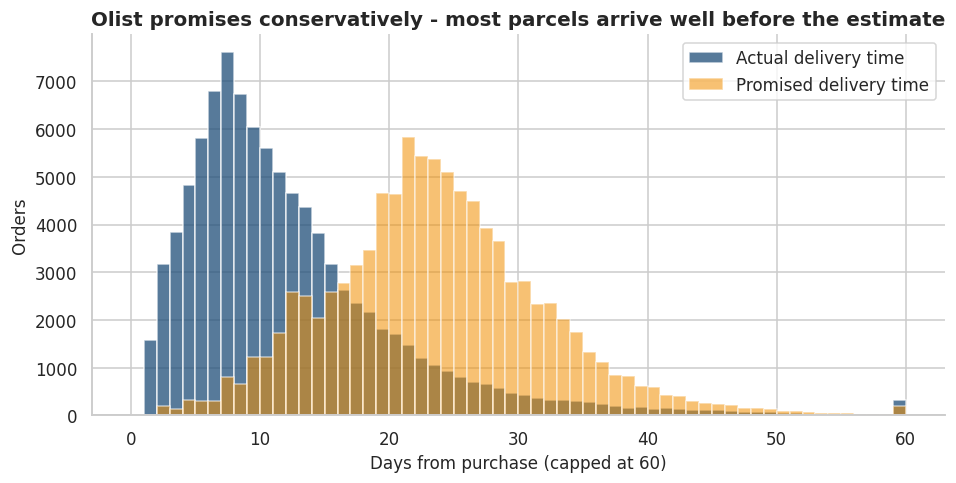

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.arange(0, 61, 1)
ax.hist(dlv["delivery_days"].clip(upper=60), bins=bins, alpha=0.75, color=oa.BASE, label="Actual delivery time")
ax.hist(dlv["promised_days"].clip(upper=60), bins=bins, alpha=0.55, color=oa.PALETTE[2], label="Promised delivery time")
ax.set_xlabel("Days from purchase (capped at 60)")
ax.set_ylabel("Orders")
ax.set_title("Olist promises conservatively - most parcels arrive well before the estimate")
ax.legend()
oa.save(fig, "03_promise_vs_actual")
plt.show()

The estimated date is padded by roughly **12 days** at the median (median actual 10.2 days vs 23.2 promised). That keeps the late rate low, but a long promise can also cost
conversions at checkout - a trade-off worth flagging to the business.

## 3 · When and where deliveries are late

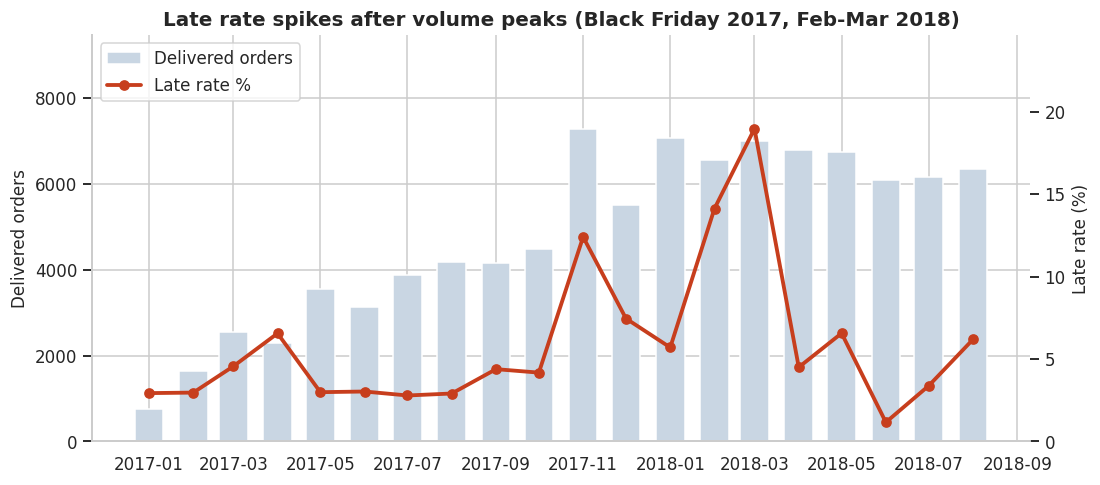

,orders,late_rate,median_days
purchase_month,,,
2018-03-01 00:00:00,7003,19.0%,13.4
2018-02-01 00:00:00,6555,14.1%,14.3
2017-11-01 00:00:00,7288,12.4%,12.7
2017-12-01 00:00:00,5513,7.5%,13.1


In [5]:
by_month = dlv.groupby("purchase_month").agg(orders=("order_id", "count"), late_rate=("is_late", "mean"),
                                             median_days=("delivery_days", "median"))
fig, ax1 = plt.subplots(figsize=(11, 4.8))
bars = ax1.bar(by_month.index, by_month["orders"], width=20, color="#c9d6e3", label="Delivered orders")
ax1.set_ylabel("Delivered orders")
ax1.set_ylim(0, by_month["orders"].max() * 1.3)
ax2 = ax1.twinx()
line, = ax2.plot(by_month.index, by_month["late_rate"] * 100, color=oa.ACCENT, marker="o", lw=2.5, label="Late rate %")
ax2.set_ylabel("Late rate (%)")
ax2.grid(False)
ax2.set_ylim(0, by_month["late_rate"].max() * 100 * 1.3)
ax1.set_title("Late rate spikes after volume peaks (Black Friday 2017, Feb-Mar 2018)")
ax1.legend(handles=[bars, line], loc="upper left", frameon=True)
oa.save(fig, "03_late_rate_by_month")
plt.show()
by_month.sort_values("late_rate", ascending=False).head(4).style.format({"late_rate": "{:.1%}", "median_days": "{:.1f}"})

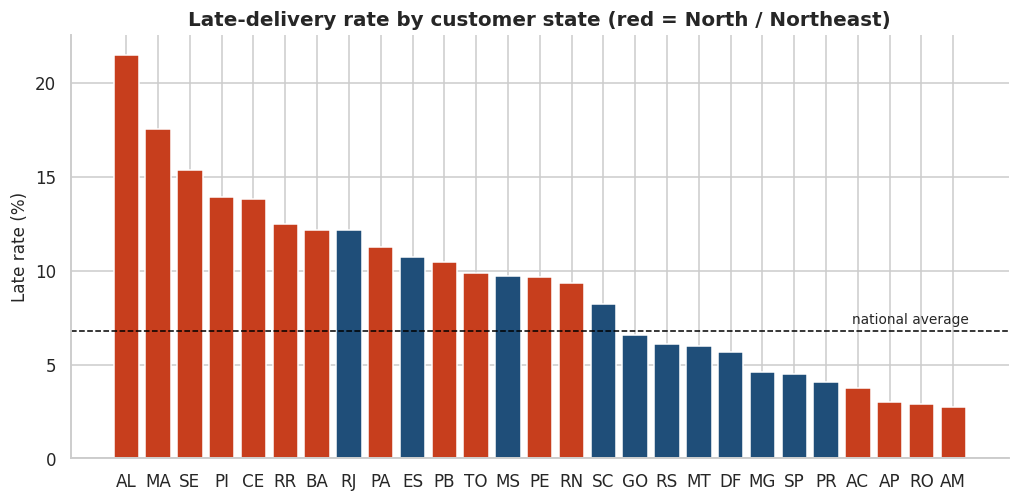

customer_state,customer_region,orders,late_rate,median_days,avg_review
AL,Northeast,396,21.5%,22.3,3.85
MA,Northeast,713,17.5%,19.2,3.83
SE,Northeast,332,15.4%,17.9,3.90
PI,Northeast,475,13.9%,16.3,3.99
CE,Northeast,1273,13.8%,18.2,3.94
RR,North,40,12.5%,25.1,3.90


In [6]:
by_state = (dlv.groupby(["customer_state", "customer_region"])
               .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"),
                    median_days=("delivery_days", "median"), avg_review=("review_score", "mean"))
               .reset_index().sort_values("late_rate", ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors = [oa.ACCENT if r in ("Northeast", "North") else oa.BASE for r in by_state["customer_region"]]
ax.bar(by_state["customer_state"], by_state["late_rate"] * 100, color=colors)
ax.axhline(dlv["is_late"].mean() * 100, color="black", ls="--", lw=1)
ax.text(len(by_state) - 0.5, dlv["is_late"].mean() * 100 + 0.4, "national average", ha="right", fontsize=9)
ax.set_ylabel("Late rate (%)")
ax.set_title("Late-delivery rate by customer state (red = North / Northeast)")
oa.save(fig, "03_late_rate_by_state")
plt.show()
by_state.head(6).style.format({"late_rate": "{:.1%}", "median_days": "{:.1f}", "avg_review": "{:.2f}"}).hide(axis="index")

## 4 · The cost of lateness: review scores

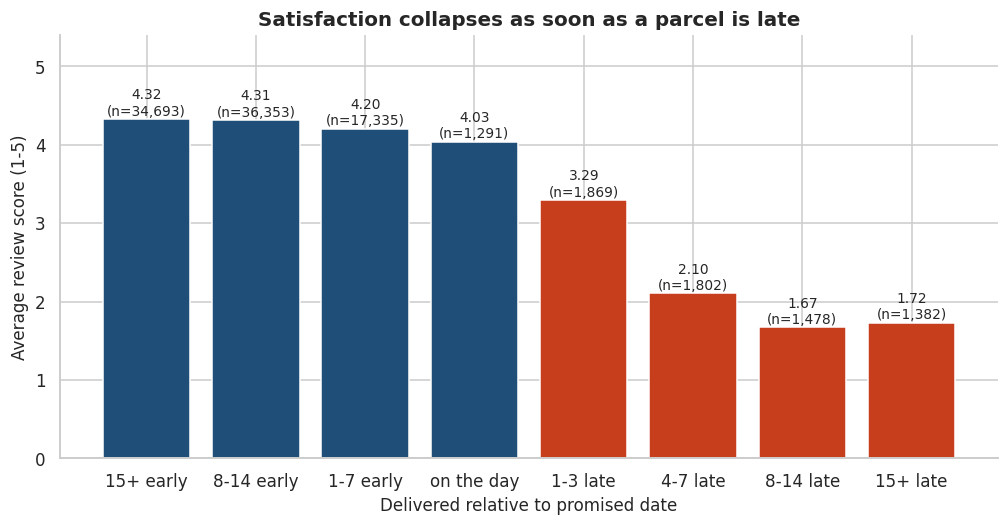

,orders,avg_review,low_review_rate
delay_bucket,,,
15+ early,"34,693",4.32,9.0%
8-14 early,"36,353",4.31,8.9%
1-7 early,"17,335",4.20,10.2%
on the day,"1,291",4.03,12.4%
1-3 late,"1,869",3.29,32.1%
4-7 late,"1,802",2.10,67.7%
8-14 late,"1,478",1.67,80.2%
15+ late,"1,382",1.72,78.3%


In [7]:
buckets = pd.cut(dlv["delay_days"], bins=[-1000, -15, -8, -1, 0, 3, 7, 14, 1000],
                 labels=["15+ early", "8-14 early", "1-7 early", "on the day", "1-3 late", "4-7 late", "8-14 late", "15+ late"])
impact = (dlv.assign(delay_bucket=buckets)
             .groupby("delay_bucket", observed=True)
             .agg(orders=("order_id", "count"), avg_review=("review_score", "mean"), low_review_rate=("is_low_review", "mean")))

fig, ax = plt.subplots(figsize=(11, 5))
colors = [oa.BASE] * 4 + [oa.ACCENT] * 4
ax.bar(impact.index.astype(str), impact["avg_review"], color=colors)
for x, (v, n) in enumerate(zip(impact["avg_review"], impact["orders"])):
    ax.text(x, v + 0.05, f"{v:.2f}\n(n={n:,})", ha="center", fontsize=9)
ax.set_ylim(0, 5.4)
ax.set_ylabel("Average review score (1-5)")
ax.set_xlabel("Delivered relative to promised date")
ax.set_title("Satisfaction collapses as soon as a parcel is late")
oa.save(fig, "03_review_vs_delay")
plt.show()
impact.style.format({"avg_review": "{:.2f}", "low_review_rate": "{:.1%}", "orders": "{:,}"})

In [8]:
on_time_low = dlv.loc[dlv["is_late"] == 0, "is_low_review"].mean()
late_low = dlv.loc[dlv["is_late"] == 1, "is_low_review"].mean()
print(f"1-2 star reviews: {on_time_low:.1%} of on-time orders vs {late_low:.1%} of late orders "
      f"({late_low / on_time_low:.1f}x more likely).")
share_low_from_late = dlv.loc[dlv["is_low_review"] == 1, "is_late"].mean()
print(f"Late orders are {dlv['is_late'].mean():.1%} of deliveries but {share_low_from_late:.1%} of all 1-2 star reviews.")

1-2 star reviews: 9.2% of on-time orders vs 62.4% of late orders (6.7x more likely).
Late orders are 6.8% of deliveries but 32.6% of all 1-2 star reviews.


## 5 · Root causes

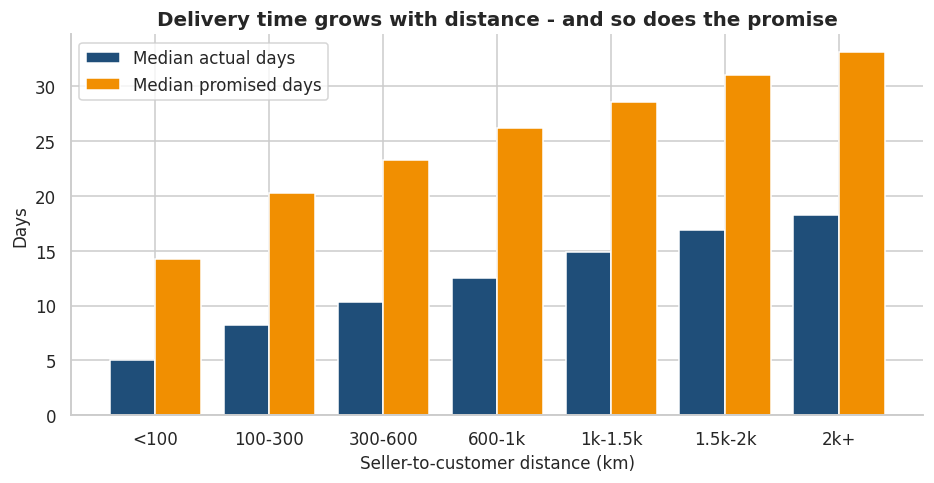

,orders,median_days,median_promised,late_rate
distance_band,,,,
<100,"17,847",5.1,14.3,4.5%
100-300,"13,319",8.2,20.2,5.2%
300-600,"31,408",10.3,23.2,6.8%
600-1k,"17,855",12.5,26.1,7.1%
1k-1.5k,"6,555",14.9,28.5,8.8%
1.5k-2k,"3,150",16.9,31.0,11.0%
2k+,"5,592",18.2,33.1,12.1%


In [9]:
dist_bins = pd.cut(dlv["distance_km"], bins=[0, 100, 300, 600, 1000, 1500, 2000, 4000],
                   labels=["<100", "100-300", "300-600", "600-1k", "1k-1.5k", "1.5k-2k", "2k+"], include_lowest=True)
by_dist = dlv.assign(distance_band=dist_bins).groupby("distance_band", observed=True).agg(
    orders=("order_id", "count"), median_days=("delivery_days", "median"),
    median_promised=("promised_days", "median"), late_rate=("is_late", "mean"))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(by_dist))
ax.bar(x - 0.2, by_dist["median_days"], 0.4, color=oa.BASE, label="Median actual days")
ax.bar(x + 0.2, by_dist["median_promised"], 0.4, color=oa.PALETTE[2], label="Median promised days")
ax.set_xticks(x, by_dist.index.astype(str))
ax.set_xlabel("Seller-to-customer distance (km)")
ax.set_ylabel("Days")
ax.set_title("Delivery time grows with distance - and so does the promise")
ax.legend()
oa.save(fig, "03_distance_effect")
plt.show()
by_dist.style.format({"late_rate": "{:.1%}", "median_days": "{:.1f}", "median_promised": "{:.1f}", "orders": "{:,}"})

In [10]:
handover = dlv.groupby("seller_missed_handover").agg(orders=("order_id", "count"), late_rate=("is_late", "mean"),
                                                    avg_review=("review_score", "mean"))
handover.index = handover.index.map({False: "Seller met shipping limit", True: "Seller missed shipping limit"})
handover.style.format({"late_rate": "{:.1%}", "avg_review": "{:.2f}", "orders": "{:,}"})

,orders,late_rate,avg_review
seller_missed_handover,,,
Seller met shipping limit,"87,622",5.4%,4.20
Seller missed shipping limit,"8,581",21.1%,3.70


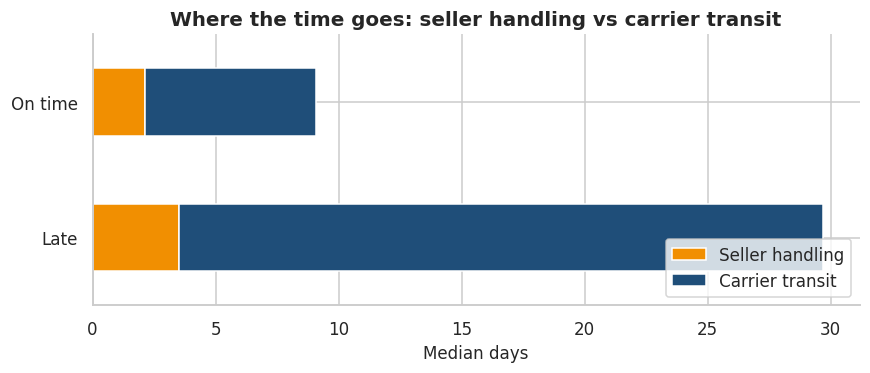

,handling_days,transit_days
is_late,,
Late,3.50,26.20
On time,2.14,6.95


In [11]:
stages = (dlv.dropna(subset=["handling_days", "transit_days"])
             .groupby(dlv["is_late"].map({0.0: "On time", 1.0: "Late"}))[["handling_days", "transit_days"]].median())
fig, ax = plt.subplots(figsize=(9, 3.2))
stages.plot.barh(stacked=True, color=[oa.PALETTE[2], oa.BASE], ax=ax)
ax.set_xlabel("Median days")
ax.set_ylabel("")
ax.set_title("Where the time goes: seller handling vs carrier transit")
ax.legend(["Seller handling", "Carrier transit"], loc="lower right")
oa.save(fig, "03_stage_breakdown")
plt.show()
stages

## 6 · Seller scorecard (sellers with 100+ delivered orders)

205 sellers with 100+ orders handle 60% of deliveries.


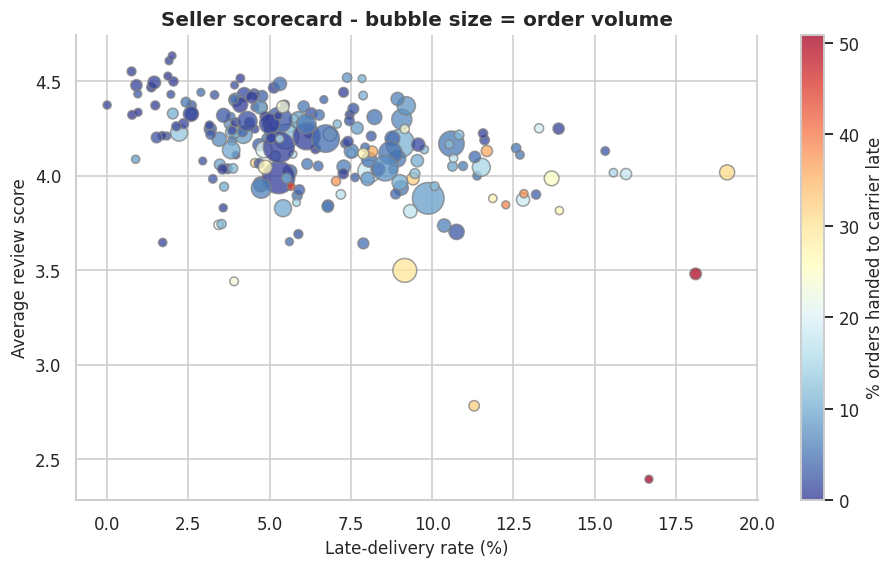

Correlation late rate vs avg review: -0.45


,orders,late_rate,missed_handover,avg_review,seller_state
main_seller_id,,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,388,19.1%,31.2%,4.02,MA
88460e8ebdecbfecb5f9601833981930,232,18.1%,50.0%,3.48,PR
1ca7077d890b907f89be8c954a02686a,108,16.7%,50.9%,2.39,SP
e5a3438891c0bfdb9394643f95273d8e,213,16.0%,17.8%,4.01,SP
cd68562d3f44870c08922d380acae552,122,15.6%,14.8%,4.02,SP
2c9e548be18521d1c43cde1c582c6de8,124,15.3%,2.4%,4.13,SP
431af27f296bc6519d890aa5a05fdb11,115,13.9%,26.1%,3.82,SP
f7ba60f8c3f99e7ee4042fdef03b70c4,216,13.9%,0.9%,4.25,SP


In [12]:
sellers = (dlv.groupby("main_seller_id")
              .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"),
                   missed_handover=("seller_missed_handover", "mean"), avg_review=("review_score", "mean"),
                   seller_state=("seller_state", "first"))
              .query("orders >= 100"))
print(f"{len(sellers)} sellers with 100+ orders handle {sellers['orders'].sum() / len(dlv):.0%} of deliveries.")

fig, ax = plt.subplots(figsize=(10, 5.5))
sc = ax.scatter(sellers["late_rate"] * 100, sellers["avg_review"], s=sellers["orders"] / 4,
                c=sellers["missed_handover"] * 100, cmap="RdYlBu_r", alpha=0.75, edgecolor="grey")
plt.colorbar(sc, label="% orders handed to carrier late")
ax.set_xlabel("Late-delivery rate (%)")
ax.set_ylabel("Average review score")
ax.set_title("Seller scorecard - bubble size = order volume")
oa.save(fig, "03_seller_scorecard")
plt.show()

print("Correlation late rate vs avg review:", round(sellers["late_rate"].corr(sellers["avg_review"]), 2))
sellers.sort_values("late_rate", ascending=False).head(8).style.format(
    {"late_rate": "{:.1%}", "missed_handover": "{:.1%}", "avg_review": "{:.2f}"})

## Summary & recommendations

| Finding (delivered orders, Jan 2017 - Aug 2018) | Recommendation |
|---|---|
| Late orders average **2.27★ vs 4.29★** on time; they are **6.8 %** of deliveries but **32.6 %** of all 1-2★ reviews. Even 4-7 days late drops the average to 2.10★ | Treat on-time delivery as the #1 satisfaction lever; send proactive delay notifications before the promised date |
| Late rate jumped to **12.4 %** (Nov 2017), **14.1 %** (Feb 2018) and **19.0 %** (Mar 2018) after demand peaks | Reserve carrier capacity and temporarily widen promises around peak periods |
| Northeast states are late most often (Alagoas **21.5 %**, Maranhão **17.5 %**); late rate rises from **4.5 %** under 100 km to **12.1 %** beyond 2,000 km | Region-specific promise dates; regional fulfilment partners or stock positioned closer to the Northeast |
| Orders where the seller missed the shipping limit are late **21.1 %** of the time vs **5.4 %** | Seller SLA monitoring; ranking boosts / penalties tied to hand-over speed |
| For late orders the carrier leg takes a median **26.2 days** vs **7.0** on time, while seller handling only grows from 2.1 to 3.5 days | Carrier scorecards and lane-level renegotiation - the transit leg is where delays accumulate |
| Promises are padded by ~12 days | Test tighter, data-driven promise dates (see the prediction model in notebook 05) |

➡️ Next: [04 · Statistics & Customer Segmentation](04_statistics_segmentation.ipynb)